In this notebook, we investigate localized (single grid-cell) precipitation and pressure. This is used to reproduce figures 5, 6, and 7, as well as some plots not in the paper. 

In [1]:
import cftime
import datetime
import matplotlib.pyplot as plt
from mpl_toolkits import axisartist
import numpy as np
import os
import xarray as xr

# Homemade routines
from ep_processing import *
from utils.visualization import *

# Plotting stuff
TITLE_FONT_SIZE = 15
TICK_FONT_SIZE = 15

plt.rc('axes', labelsize = TITLE_FONT_SIZE)
plt.rc('xtick', labelsize = TICK_FONT_SIZE)   
plt.rc('ytick', labelsize = TICK_FONT_SIZE)

In [2]:
my_base_path = "~/Documents/research/experiment-outputs/{experiment_name}/{runid}/"
my_generic_file_path = "_day_CanESM5-1_{experiment_name}_r1i1p1f1_gn_{year}0101-{year}1231.nc"

my_pr_file_path = "pr" + my_generic_file_path
my_prc_file_path = "prc" + my_generic_file_path
my_ps_file_path = "ps" + my_generic_file_path
my_wap_file_path = "wap" + my_generic_file_path

my_experiment_name = "amip"
my_runid = "agm-amip-test"
year_start = 2003
year_end = 2008 + 1
year_range = range(year_start, year_end)

In [3]:
# Daily surface pressure (obtained by post-processing/downsampling model outputs)
ds_ps_daily = get_ds(
        "ps",
        my_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_ps_file_path,
)

# Daily precipitation 
ds_pr_daily = get_ds(
        "pr",
        my_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_pr_file_path,
)

# Daily convective precipitation 
ds_prc_daily = get_ds(
        "prc",
        my_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_prc_file_path,
)

# Daily resolved precip
da_prr_daily = ds_pr_daily.pr - ds_prc_daily.prc

# Daily WAP @ 500 hPa = 5e3 Pa
ds_wap_daily =  get_ds(
        "wap",
        my_runid,
        my_experiment_name,
        year_range,
        base_path = my_base_path,
        file_path = my_wap_file_path,
).sel(plev = 500 * 100)

In [4]:
da_ps_daily = ds_ps_daily.ps

By commenting/uncommenting appropriate lines below, you can either use the grid boxes from the paper *or* select a grid box (uniform-) randomly.

In [5]:
# my_random_seed = 32
# rng = np.random.default_rng() #seed = my_random_seed)
# random_lat = rng.integers(
#     low = 32, # -13. 
#     high = 58,  # 13.
#     size = 1,
# )[0]
# random_lon = rng.integers(
#     low = 180, 
#     high = 360, 
#     size = 1,
# )[0]
#random_lat = 4.2
random_lat = 46.
random_lon = 335.

In [6]:
# To make sure everything is as honest as possible, make sure we pick a random_lat, random_lon *inside
# an actual grid cell*

# Use trick here: https://stackoverflow.com/questions/2566412/find-nearest-value-in-numpy-array

def get_closest_entry(x, y0):
    """
    Returns the entry of the array x closest to some float y0
    """
    return x[np.abs(x - y0).argmin()]

lats = da_ps_daily.lat.values
random_lat = get_closest_entry(lats, random_lat)

lons = da_ps_daily.lon.values
random_lon = get_closest_entry(lons, random_lon)

In [7]:
random_lat, random_lon

(np.float64(46.044726631101724), np.float64(334.6875))

In [8]:
box_size_in_degrees = 42

def make_centred_slice(centre, width):
    return slice(centre - 0.5 * width, centre + 0.5 * width)
    
lat_slice = make_centred_slice(random_lat, box_size_in_degrees)
lon_slice = make_centred_slice(random_lon, box_size_in_degrees)

In [9]:
da_ps_localized = ds_ps_daily.ps.sel(lat = lat_slice, lon = lon_slice)
da_pr_localized = ds_pr_daily.pr.sel(lat = lat_slice, lon = lon_slice)
da_wap_localized = ds_wap_daily.wap.sel(lat = lat_slice, lon = lon_slice)

In [10]:
da_ps_localized = 1e-2 * da_ps_localized # to hPa
da_pr_localized = 86400. * da_pr_localized # to mm/day
# Note: wap in Pa/s, we shall not change units 

### Obtaining Anomalies

In [11]:
pr_central_grid_box = da_pr_localized.sel(lat = random_lat, lon = random_lon, method = "nearest")

In [12]:
ps_on_epe_days = []
wap_on_epe_days = []
epe_intensity = []

for year in year_range:
    day_of_epe = get_day_of_extreme(pr_central_grid_box, year).values
    epe_intensity.append(pr_central_grid_box.sel(time = day_of_epe).values)
    
    ps_on_epe_day_current_year = da_ps_localized.sel(time = day_of_epe, method = "ffill")
    ps_on_epe_days.append(ps_on_epe_day_current_year)

    wap_on_epe_day_current_year = da_wap_localized.sel(time = day_of_epe, method = "ffill")
    wap_on_epe_days.append(wap_on_epe_day_current_year)

da_ps_on_epe_days = to_yearly_dataarray(da_ps_localized, ps_on_epe_days, year_range)
da_wap_on_epe_days = to_yearly_dataarray(da_wap_localized, wap_on_epe_days, year_range)

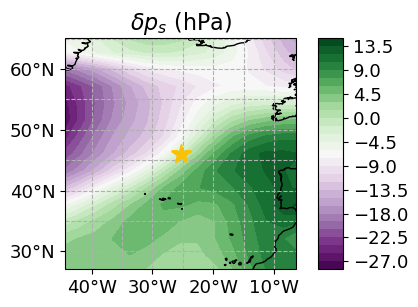

In [13]:
ps_epe_anom = (da_ps_on_epe_days - da_ps_localized.mean(dim="time")).sel(time = 2005) #.mean(dim="time")

vmin = -15. # epe_anom.min().values
vmax = 15. # epe_anom.max().values

local_bbox = [
    random_lon - 0.5 * box_size_in_degrees,
    random_lon + 0.5 * box_size_in_degrees,
    random_lat - 0.5 * box_size_in_degrees,
    random_lat + 0.5 * box_size_in_degrees,
]

draw_global_map(
        ps_epe_anom.lon,
        ps_epe_anom.lat,
        ps_epe_anom.to_numpy(),
        title = r"$\delta p_s$ (hPa)",
        filled = True,
        show_fig = True,
        save_fig = False,
        levels = 30,
        # bbox = [local_bbox[0] + 2, 350, 30, 63], 
        bbox = [local_bbox[0] + 2, local_bbox[1] - 2, local_bbox[2] + 2, local_bbox[3] - 2], 
        cmap = "PRGn",
        cbar_params = [0.65, 0.11, 0.025, 0.77], # position, upper offset, width, cbar length
        xtickdelta = 10,
        ytickdelta = 10,
        figsize = (10, 3),
        point_to_label = [random_lon, random_lat],
        point_to_label_color = "xkcd:goldenrod",
        #vmin = vmin,
        #vmax = vmax,
        draw_labels = False,
        label_contours = False,
        remove_cbar = False,
        fig = None,
        projection = ccrs.PlateCarree(central_longitude = 180),
        #outfilename = "special_point_medium" + ".png",
)

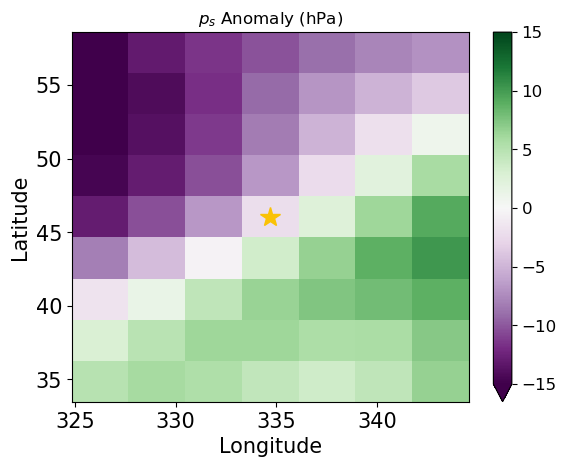

In [14]:
dx = 2.8 
box_size = 2 * dx

fig, ax = plt.subplots(
            1,
            1,
            # subplot_kw={"projection": ccrs.PlateCarree(central_longitude = 180)}
)

ps_epe_anom.sel(
    lon = slice(random_lon - 2 * box_size, random_lon + 2 * box_size),
    lat = slice(random_lat - 2 * box_size, random_lat + 2 * box_size),
).plot(
    ax = ax, 
    vmin = -15, 
    vmax = 15, 
    cmap = "PRGn", 
    cbar_kwargs={
        "label": None,
        "pad": 0.05,
    },
)

cbar = plt.gcf().axes[-1] # Grabs the colorbar axis
cbar.tick_params(labelsize = 12)

plt.title(r"$p_s$ Anomaly (hPa)", fontsize = 12)

ax.plot(
           random_lon,
           random_lat,
           marker="*",
           color= "xkcd:goldenrod",
           markersize=15,
           # transform = ccrs.PlateCarree(central_longitude = 180),
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [15]:
ps_epe_anom_all_zoomed = (da_ps_on_epe_days - da_ps_localized.mean(dim="time")).sel(
    lon = slice(random_lon - 2 * box_size, random_lon + 2 * box_size),
    lat = slice(random_lat - 2 * box_size, random_lat + 2 * box_size),
)
ps_epe_anom_min = ps_epe_anom_all_zoomed.min().values
ps_epe_anom_max = ps_epe_anom_all_zoomed.max().values

vmin = np.floor(min(-np.abs(ps_epe_anom_min), -np.abs(ps_epe_anom_max)))
vmax = np.ceil(max(np.abs(ps_epe_anom_min), np.abs(ps_epe_anom_max)))

Running the next grid box reproduces fig. 5. 

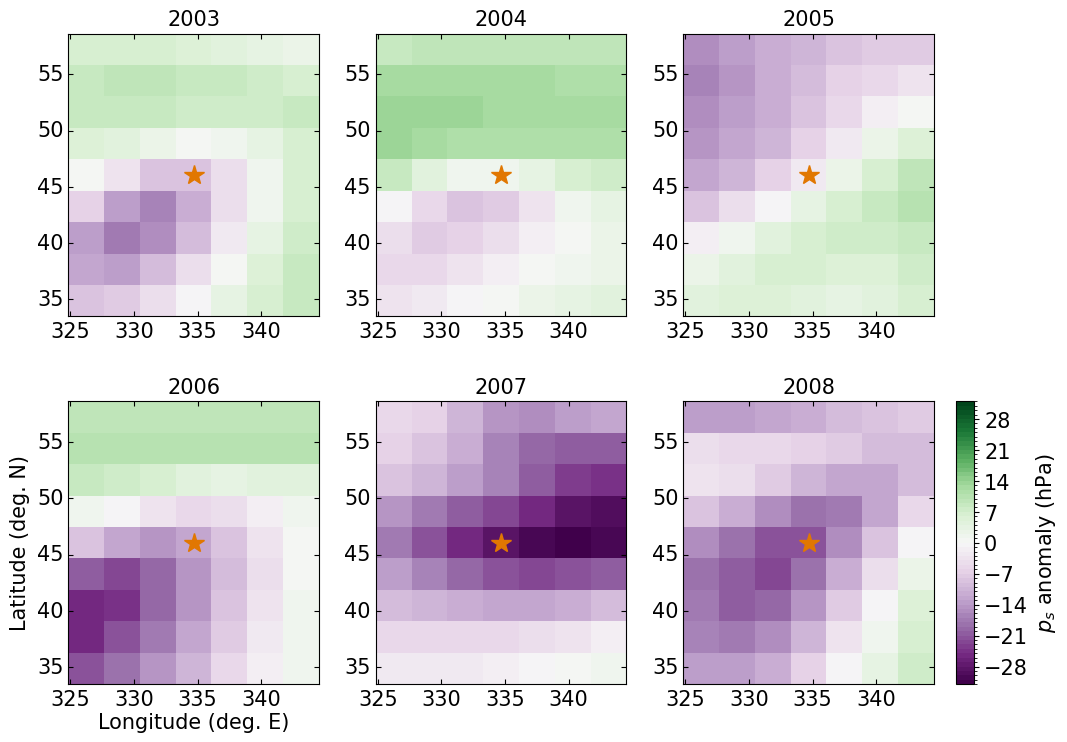

In [16]:
# plt.rc('font', family='serif')

fig = plt.figure(figsize=(12, 18))

gs = fig.add_gridspec(4, 4, width_ratios=[1, 1, 1, 0.03])
gs.update(wspace=0.3, hspace=0.3)

row_idx = 0
col_idx = 0

for year in year_range:
    ax = fig.add_subplot(
        gs[row_idx, col_idx],
        axes_class = axisartist.axislines.AxesZero,
    )

    ps_epe_anom_current_year = ps_epe_anom_all_zoomed.sel(time = year)
        
    ps_anom_plot = ps_epe_anom_current_year.plot(
        ax = ax,
        add_colorbar = False,
        add_labels = False,
        vmin = vmin,
        vmax = vmax,
        levels = 1 + int(2 * vmax),
        cmap = "PRGn", 
    )

    ax.plot(
           random_lon,
           random_lat,
           marker="*",
           color= "xkcd:pumpkin",
           markersize = 15,
           # transform = ccrs.PlateCarree(central_longitude = 180),
    )

    ax.set_title(year, fontsize = TITLE_FONT_SIZE)
    ax.tick_params(axis='both', labelsize = TITLE_FONT_SIZE)

    if row_idx == 1 and col_idx == 0:
        ax.set_xlabel("Longitude (deg. E)", fontsize = 100)
        ax.set_ylabel("Latitude (deg. N)")

    if year == 2005:
        row_idx += 1
    
    col_idx += 1
    col_idx = col_idx % 3

# Hack to get the colorbar axes position looking good...manually
# massage the bbox!
my_cax = fig.add_subplot(gs[1,3])
pos = my_cax.get_position()
pos.x0 = 0.865
pos.x1 = pos.x0 + 0.015
my_cax.set_position(pos)

# Finally draw the colorbar itself
plt.colorbar(
            ps_anom_plot,
            ax = ax,
            cax = my_cax,
)

my_cax.tick_params(labelsize = TICK_FONT_SIZE)
my_cax.set_ylabel(r"$p_s$ anomaly (hPa)", fontsize = TITLE_FONT_SIZE)

# Save output
#outfile_path = "images/" + "ps_anom_localized_gallery" + ".png"
#plt.savefig(outfile_path, dpi=600, bbox_inches='tight')

plt.show()

We can also look at the vertical pressure-coordinate velocity to make sure extreme events do coincide with strong ascent. 

In [17]:
wap_epe_anom = (da_wap_on_epe_days - da_wap_localized.mean(dim="time")).sel(time = 2005) #.mean(dim="time")
# year 2005 is very weird! 

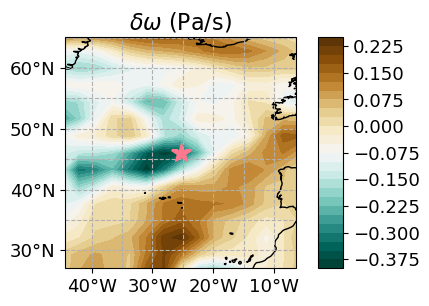

In [18]:
draw_global_map(
        wap_epe_anom.lon,
        wap_epe_anom.lat,
        wap_epe_anom.to_numpy(),
        title = r"$\delta \omega$ (Pa/s)",
        filled = True,
        show_fig = True,
        save_fig = False,
        levels = 30,
        # bbox = [local_bbox[0] + 2, 350, 30, 63], 
        bbox = [local_bbox[0] + 2, local_bbox[1] - 2, local_bbox[2] + 2, local_bbox[3] - 2], 
        cmap = "BrBG_r",
        cbar_params = [0.65, 0.11, 0.025, 0.77], # position, upper offset, width, cbar length
        xtickdelta = 10,
        ytickdelta = 10,
        figsize = (10, 3),
        point_to_label = [random_lon, random_lat],
        point_to_label_color = "xkcd:carnation",
        #vmin = -0.02,
        #vmax = 0.02,
        draw_labels = False,
        label_contours = False,
        remove_cbar = False,
        fig = None,
        projection = ccrs.PlateCarree(central_longitude = 180),
        # outfilename = "special_point_medium" + ".png",
)

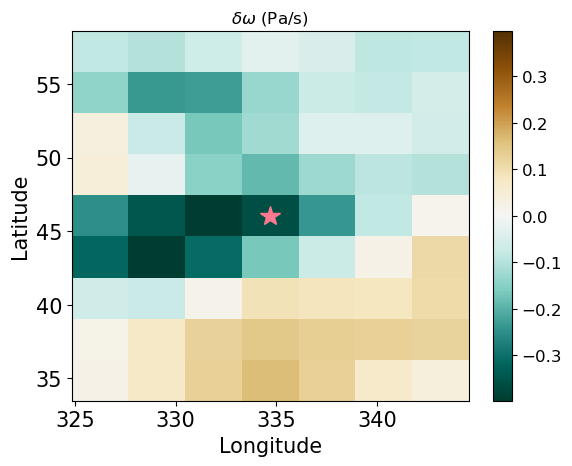

In [19]:
fig, ax = plt.subplots(
            1,
            1,
            # subplot_kw={"projection": ccrs.PlateCarree(central_longitude = 180)}
)

wap_epe_anom.sel(
    lon = slice(random_lon - 2 * box_size, random_lon + 2 * box_size),
    lat = slice(random_lat - 2 * box_size, random_lat + 2 * box_size),
).plot(
    ax = ax, 
    #vmin = -0.02,
    #vmax = 0.02, 
    cmap = "BrBG_r", 
    cbar_kwargs={
        "label": None,
        "pad": 0.05,
    },
)

cbar = plt.gcf().axes[-1] # Grabs the colorbar axis
cbar.tick_params(labelsize = 12)

plt.title(r"$\delta\omega$ (Pa/s)", fontsize = 12)

ax.plot(
           random_lon,
           random_lat,
           marker="*",
           color= "xkcd:carnation",
           markersize=15,
           # transform = ccrs.PlateCarree(central_longitude = 180),
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")

plt.show()

In [20]:
wap_epe_anom_all_zoomed = (da_wap_on_epe_days - da_wap_localized.mean(dim="time")).sel(
    lon = slice(random_lon - 2 * box_size, random_lon + 2 * box_size),
    lat = slice(random_lat - 2 * box_size, random_lat + 2 * box_size),
)
wap_epe_anom_min = wap_epe_anom_all_zoomed.min().values
wap_epe_anom_max = wap_epe_anom_all_zoomed.max().values

vmin = min(-np.abs(wap_epe_anom_min), -np.abs(wap_epe_anom_max))
vmax = max(np.abs(wap_epe_anom_min), np.abs(wap_epe_anom_max))

In [21]:
wap_epe_anom_min

array(-0.6259093, dtype=float32)

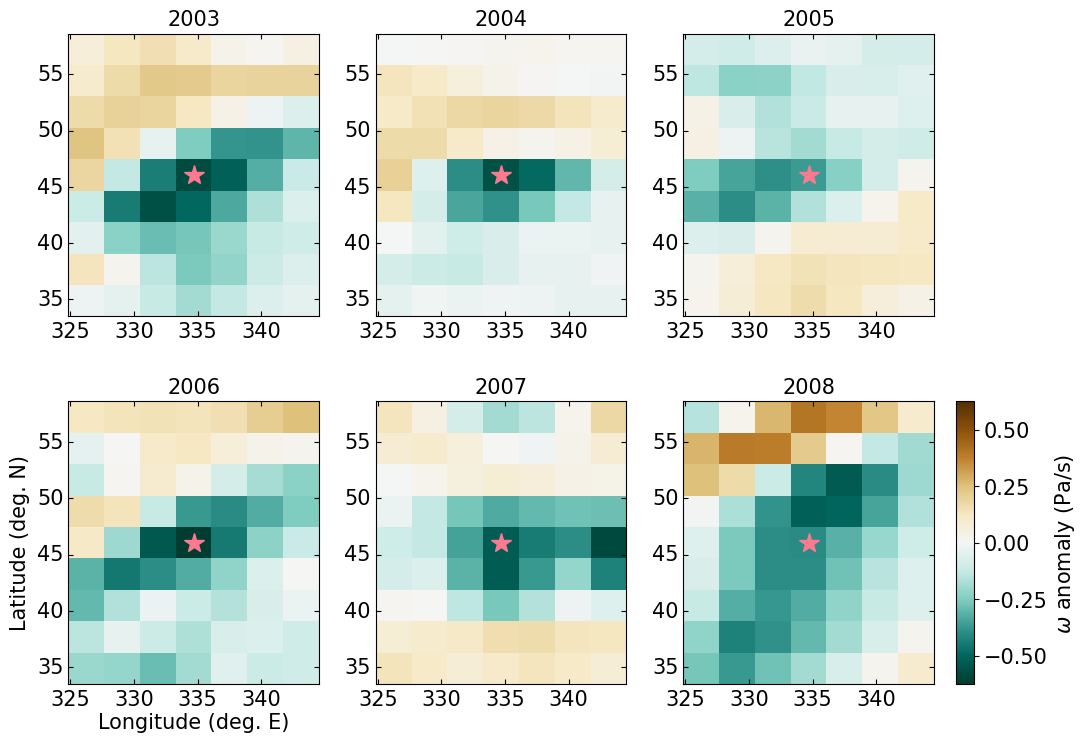

In [22]:
# plt.rc('font', family='serif')

fig = plt.figure(figsize=(12, 18))

gs = fig.add_gridspec(4, 4, width_ratios=[1, 1, 1, 0.03])
gs.update(wspace=0.3, hspace=0.3)

row_idx = 0
col_idx = 0

for year in year_range:
    ax = fig.add_subplot(
        gs[row_idx, col_idx],
        axes_class = axisartist.axislines.AxesZero,
    )

    wap_epe_anom_current_year = wap_epe_anom_all_zoomed.sel(time = year)
        
    wap_anom_plot = wap_epe_anom_current_year.plot(
        ax = ax,
        add_colorbar = False,
        add_labels = False,
        vmin = vmin,
        vmax = vmax,
        # levels = 1 + int(2 * vmax),
        cmap = "BrBG_r", 
    )

    ax.plot(
           random_lon,
           random_lat,
           marker="*",
           color= "xkcd:carnation",
           markersize = 15,
           # transform = ccrs.PlateCarree(central_longitude = 180),
    )

    ax.set_title(year, fontsize = TITLE_FONT_SIZE)
    ax.tick_params(axis='both', labelsize = TITLE_FONT_SIZE)

    if row_idx == 1 and col_idx == 0:
        ax.set_xlabel("Longitude (deg. E)")
        ax.set_ylabel("Latitude (deg. N)")

    if year == 2005:
        row_idx += 1
    
    col_idx += 1
    col_idx = col_idx % 3

# Hack to get the colorbar axes position looking good...manually
# massage the bbox!
my_cax = fig.add_subplot(gs[1,3])
pos = my_cax.get_position()
pos.x0 = 0.865
pos.x1 = pos.x0 + 0.015
my_cax.set_position(pos)

# Finally draw the colorbar itself
plt.colorbar(
            wap_anom_plot,
            ax = ax,
            cax = my_cax,
)

my_cax.tick_params(labelsize = TICK_FONT_SIZE)
my_cax.set_ylabel(r"$\omega$ anomaly (Pa/s)", fontsize = TITLE_FONT_SIZE)

# Save output
#outfile_path = "images/" + "wap_anom_localized_gallery" + ".png"
#plt.savefig(outfile_path, dpi=600, bbox_inches='tight')

plt.show()

## Time Series of Precipitation

In this section, we look at time series of precipitation around each EPE in the sample period. This allows us to reproduce figures 5 and 6 (note: the code defaults to fig. 6... you will have to re-run the notebook with a different `random_lat, random_lon` to switch to fig. 5)! 

In [23]:
da_prc_localized = 86400. * ds_prc_daily.prc.sel(lat = lat_slice, lon = lon_slice)
da_prr_localized = 86400. * da_prr_daily.sel(lat = lat_slice, lon = lon_slice)

In [24]:
da_pr_in_central_box = da_pr_localized.sel(lon = random_lon, lat = random_lat)
da_prc_in_central_box = da_prc_localized.sel(lon = random_lon, lat = random_lat)
da_prr_in_central_box = da_prr_localized.sel(lon = random_lon, lat = random_lat)

In [25]:
# half-width of time series interval
time_slice_half_width = 10 # in days
my_time_delta = datetime.timedelta(days = time_slice_half_width)

pr_in_central_box_in_epe_slice = np.zeros((year_end - year_start, 1 + 2 * time_slice_half_width), dtype = float)
prc_in_central_box_in_epe_slice = np.copy(pr_in_central_box_in_epe_slice )
prr_in_central_box_in_epe_slice = np.copy(pr_in_central_box_in_epe_slice )

for year_index in range(0, year_end - year_start):
    year = year_start + year_index
    
    day_of_epe = get_day_of_extreme(da_pr_in_central_box, year).values.item()
    time_slice = slice(day_of_epe - my_time_delta, day_of_epe + my_time_delta)
    
    pr_in_central_box_in_epe_slice[year_index, :] = da_pr_in_central_box.sel(time = time_slice).values
    prc_in_central_box_in_epe_slice[year_index, :] = da_prc_in_central_box.sel(time = time_slice).values
    prr_in_central_box_in_epe_slice[year_index, :] = da_prr_in_central_box.sel(time = time_slice).values

In [26]:
times = np.linspace(-10, 10, num = 21)

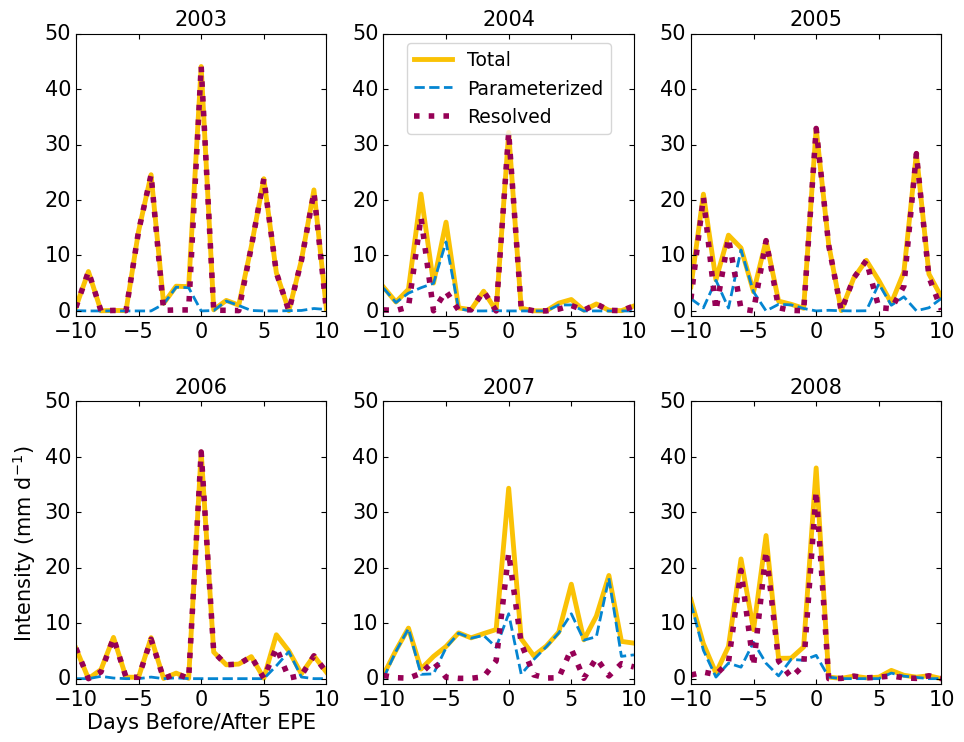

In [27]:
# plt.rc('font', family='serif')

fig = plt.figure(figsize=(12, 18))

gs = fig.add_gridspec(4, 4, width_ratios=[1, 1, 1, 0.03])
gs.update(wspace=0.3, hspace=0.3)

row_idx = 0
col_idx = 0

for year_index in range(0, year_end - year_start):
    year = year_start + year_index
    
    ax = fig.add_subplot(
        gs[row_idx, col_idx],
        axes_class = axisartist.axislines.AxesZero,
    )

    plt.plot(
        times, 
        pr_in_central_box_in_epe_slice[year_index, :],
        color = "xkcd:goldenrod",
        linestyle = "solid",
        label= "Total",
        linewidth = 3.5,
    )

    plt.plot(
        times, 
        prc_in_central_box_in_epe_slice[year_index, :],
        color = "xkcd:cerulean",
        linestyle = "dashed",
        label = "Parameterized",
        linewidth = 2,
    )

    plt.plot(
        times, 
        prr_in_central_box_in_epe_slice[year_index, :],
        color = "xkcd:dark magenta",
        linestyle = "dotted",
        label = "Resolved",
        linewidth = 4,
    )

    
    #plt.ylim(-1, 120) 
    plt.ylim(-1, 50)
    
    plt.xlim(-10, 10)

    ax.set_title(year, fontsize = TITLE_FONT_SIZE)

    if row_idx == 1 and col_idx == 0:
       ax.set_xlabel("Days Before/After EPE")
       ax.set_ylabel(r"Intensity (mm $\mathrm{d}^{-1}$)")

    if year == 2004:
       plt.legend(loc="upper center", fontsize=13.5, ncols=1)

    if year == 2005:
        row_idx += 1
    
    col_idx += 1
    col_idx = col_idx % 3

# Save output
#outfile_path = "images/" + "pr_localized_time_series_gallery_TROPICAL" + ".png"
#plt.savefig(outfile_path, dpi=600, bbox_inches='tight')

plt.show()